In [1]:
import biolqm
import ginsim
from colomoto.minibn import BooleanNetwork
from colomoto_jupyter import tabulate
import pandas as pd # for displaying list of fixpoints
import pypint

This notebook has been executed using the docker image `colomoto/colomoto-docker:2019-12-19`

In [2]:
F = BooleanNetwork()

In [3]:
a, b, c ,d , e, f = F.vars("a", "b", "c","d", "e", "f")


In [4]:
F[a] = a
F[b] = ~d&(a|c)
F[c] = b
F[d] = f
F[e] = ~d&c
F[f] = ~d&e

In [5]:
F

a <- a
b <- !d&(a|c)
c <- b
d <- f
e <- !d&c
f <- !d&e

In [6]:
lqm = F.to_biolqm()

In [23]:
trace = biolqm.trace(lqm)
pd.DataFrame( [s for s in trace] )

,a,b,c,d,e,f
0,0,0,0,0,0,0


In [8]:
fps = biolqm.fixpoints(lqm)
print(len(fps), "fixpoints")
tabulate(fps)

1 fixpoints


<table>
<thead>
<tr><th style="text-align: right;">  </th><th style="text-align: right;">  a</th><th style="text-align: right;">  b</th><th style="text-align: right;">  c</th><th style="text-align: right;">  d</th><th style="text-align: right;">  e</th><th style="text-align: right;">  f</th></tr>
</thead>
<tbody>
<tr><td style="text-align: right;"> 0</td><td style="text-align: right;">  0</td><td style="text-align: right;">  0</td><td style="text-align: right;">  0</td><td style="text-align: right;">  0</td><td style="text-align: right;">  0</td><td style="text-align: right;">  0</td></tr>
</tbody>
</table>

In [9]:
lrg = biolqm.to_ginsim(lqm)

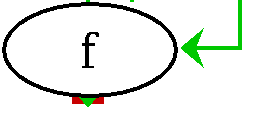

In [10]:
ginsim.show(lrg)
#ginsim.service("maboss").export(lrg, "mymodel.bnd")
#biolqm.save(lqm, "mymodel.ginml", "ginml")

### Pint

In [11]:
an = ginsim.to_pint(lrg)
graph = an.reachable_stategraph()

# computing graph layout...


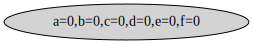

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
graph


In [13]:
attractors = an.reachable_attractors()
attractors

[{'type': 'fixpoint',
  'size': 1,
  'sample': {'a': 0, 'b': 0, 'c': 0, 'd': 0, 'e': 0, 'f': 0}}]

In [14]:
attractors[0]["sample"]

{'a': 0, 'b': 0, 'c': 0, 'd': 0, 'e': 0, 'f': 0}

In [15]:
def DecimalToBinary(num): 
  return "{0:b}".format(num).zfill(6)

attractor_lits = list()
DF_list = list()
fixpoints_counts = 0
fixpoints_lits = list()

for x in range(64):
    trace = biolqm.trace(lqm , "-u synchronous -i "+DecimalToBinary(x))
    df = pd.DataFrame(trace)
    DF_list.append(df)
    #print(df)
    last_row= df.iloc[-1,:]
    final = str(last_row["a"])+str(last_row["b"])+str(last_row["c"])+str(last_row["d"])+str(last_row["e"])+str(last_row["f"])
    if(final == "000000"):
        fixpoints_counts +=1
        fixpoints_lits.append(df)
    else: # attrctors
        df = df.applymap(str)
        attractor_lits.append(df)    

print("Attractors:"+ str(len(attractor_lits)))
print("Fixpoints:"+str(fixpoints_counts))


for items in fixpoints_lits:
        print(items)

Attractors:41
Fixpoints:23
   a  b  c  d  e  f
0  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  0  0  1
1  0  0  0  1  0  0
2  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  0  1  0
1  0  0  0  0  0  1
2  0  0  0  1  0  0
3  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  0  1  1
1  0  0  0  1  0  1
2  0  0  0  1  0  0
3  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  1  0  0
1  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  1  0  1
1  0  0  0  1  0  0
2  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  1  1  0
1  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  0  1  1  1
1  0  0  0  1  0  0
2  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  1  0  1  0
1  0  1  0  0  1  1
2  0  0  1  1  0  1
3  0  0  0  1  0  0
4  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  1  0  1  1
1  0  1  0  1  1  1
2  0  0  1  1  0  0
3  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  1  1  0  0
1  0  0  0  0  0  0
   a  b  c  d  e  f
0  0  0  1  1  0  1
1  0  0  0  1  0  0
2  0  0  0  0  0  0
   a  b  c  d

In [16]:
def ToString(row_df):
    return pd.Series(row_df.fillna('').values.tolist()).str.cat(sep='') 

def FindBasin(index,attractor,attractor_lits): 
    matched_state =[] 
    global_attrator_size = len(attractor.index)
    total_count_basin =0
    total_loop_found = 0
    local_count_basin = 0
    for local_index, local_attractor_df in enumerate(attractor_lits):  # fetch each attractor (the local attractor)
           
            if(index == local_index): # skip scan to itself
                continue
            #else: 
                 #print("attractors:"+str(local_index))
            
            local_attrator_size = len(local_attractor_df.index)
            
            for local_row_index, local_row in local_attractor_df.iterrows():#get each row of the local attractor compare to the global row
                
                str_local_row =  ToString(local_row)
                 # Find loop ( if orbit exists then continue to next iteration)
                
                
                for global_row_index, global_row in attractor.iterrows():

                        count_found_loop = 0
                        str_global_row = ToString(global_row)
                        
                        # Count basin
                        #if(str_local_row in matched_state):
                                #if(count_found_loop > 1 ):
                                #    local_count_basin = local_count_basin - count_found_loop
                        #        continue
                        #else:
                        #    matched_state.append(str_local_row)
                        #    local_count_basin+=1
                            
                        if(str_global_row == str_local_row ): 
                           # check remaing
                            count_found_loop+=1
                            i = global_row_index
                            z = local_row_index
                            while(  ( z+1 < local_attrator_size and i+1 < global_attrator_size)
                                  and (ToString(local_attractor_df.iloc[z+1]) == ToString(attractor.iloc[i+1]))  ):
                                i+=1
                                z+=1
                                count_found_loop+=1
                            
                        if(count_found_loop > 1 ): # Loop Found  
                            #print(count_found_loop)
                            #total_loop_found +=1
                            #if(str_local_row in matched_state):
                            #     pass
                            #else: 
                                j = local_row_index   
                                #print("start index:"+str(local_row_index))
                                while(j >=0  ):  # check previous 
                                    local_row = ToString(local_attractor_df.iloc[j])
                                    #print(local_row)
                                    if(local_row not in matched_state): 
                                        matched_state.append(local_row)                
                                    j-=1                                         
                        else:       
                            pass
                           
    
    for global_row_index, global_row in attractor.iterrows():
        str_global_row = ToString(global_row)
        if(str_global_row in matched_state):
            pass
        else:
            matched_state.append(str_global_row)
        
    #print("total_loop_found:"+str(total_loop_found))
    #print("Array size:"+str(len(matched_state)))
    #matched_state = list(set(matched_state))
    total_count_basin = len(matched_state) # + (global_attrator_size-1)
    print("Basin list:")
    print(matched_state)
    return total_count_basin


def FindOrbit(attractor_df):
    global_attrator_size  = len(attractor_df.index)
    index_list = list()
    for  local_index, local_row in attractor_df.iterrows():
        global_row = ToString(local_row)
        count_found_loop = 0
        z = 0
        while(z < global_attrator_size  ):
            if(global_row == ToString(attractor_df.iloc[z])):
                index_list.append(z)
                count_found_loop+=1
            z+=1
        #print(index_list)
        if(count_found_loop > 1 ):
            print("orbit:"+str(index_list[-1]-index_list[-2]))


for index,attractor_df in enumerate(attractor_lits): 
    print("attractor index:"+str(index))
    print(attractor_df)
    allstates_count_row = attractor_df.shape[0]
    count_basin= FindBasin(index,attractor_df,attractor_lits)
    FindOrbit(attractor_df)    
    print("count_basin:"+str(count_basin))
    print("basin size:"+str((count_basin/64)*100) + "%")
    #print("allstates_count_row: "+str(allstates_count_row))
    print("---ends---")
 # print(DecimalToBinary(x))

attractor index:0
   a  b  c  d  e  f
0  0  0  1  0  0  0
1  0  1  0  0  1  0
2  0  0  1  0  0  1
3  0  1  0  1  1  0
4  0  0  1  0  0  0
Basin list:
['001001', '010110', '001000', '010010', '010000', '010100', '011110', '011001', '011100']
orbit:4
orbit:4
count_basin:9
basin size:14.0625%
---ends---
attractor index:1
   a  b  c  d  e  f
0  0  0  1  0  0  1
1  0  1  0  1  1  0
2  0  0  1  0  0  0
3  0  1  0  0  1  0
4  0  0  1  0  0  1
Basin list:
['001000', '010010', '001001', '010110', '010000', '010100', '011110', '011001', '011100']
orbit:4
orbit:4
count_basin:9
basin size:14.0625%
---ends---
attractor index:2
   a  b  c  d  e  f
0  0  1  0  0  0  0
1  0  0  1  0  0  0
2  0  1  0  0  1  0
3  0  0  1  0  0  1
4  0  1  0  1  1  0
5  0  0  1  0  0  0
Basin list:
['001000', '010010', '001001', '010110', '010100', '011110', '011001', '011100', '010000']
orbit:4
orbit:4
count_basin:9
basin size:14.0625%
---ends---
attractor index:3
   a  b  c  d  e  f
0  0  1  0  0  1  0
1  0  0  1  0  0

Basin list:
['100000', '110000', '111000', '111010', '111011', '111111', '101100', '110101', '100011', '100100', '100101', '100110', '100111', '111101', '110011', '101010', '110111', '101011', '101101', '101110', '101111']
orbit:7
orbit:7
count_basin:21
basin size:32.8125%
---ends---
attractor index:22
   a  b  c  d  e  f
0  1  0  1  1  0  1
1  1  0  0  1  0  0
2  1  0  0  0  0  0
3  1  1  0  0  0  0
4  1  1  1  0  0  0
5  1  1  1  0  1  0
6  1  1  1  0  1  1
7  1  1  1  1  1  1
8  1  0  1  1  0  0
9  1  0  0  0  0  0
Basin list:
['100000', '110000', '111000', '111010', '111011', '111111', '101100', '110101', '100011', '100100', '100101', '100110', '100111', '111101', '110011', '101010', '110111', '101011', '101110', '101111', '101101']
orbit:7
orbit:7
count_basin:21
basin size:32.8125%
---ends---
attractor index:23
   a  b  c  d  e  f
0  1  0  1  1  1  0
1  1  0  0  0  0  0
2  1  1  0  0  0  0
3  1  1  1  0  0  0
4  1  1  1  0  1  0
5  1  1  1  0  1  1
6  1  1  1  1  1  1
7  1  0  1  

Basin list:
['100000', '110000', '111000', '111010', '111011', '111111', '101100', '110101', '100011', '100100', '100101', '100110', '100111', '111101', '110011', '101010', '110111', '101011', '101101', '101110', '101111']
orbit:7
orbit:7
count_basin:21
basin size:32.8125%
---ends---


In [17]:
# For test 

th17 = ginsim.load("http://ginsim.org/sites/default/files/Th_17.zginml")

Downloading http://ginsim.org/sites/default/files/Th_17.zginml

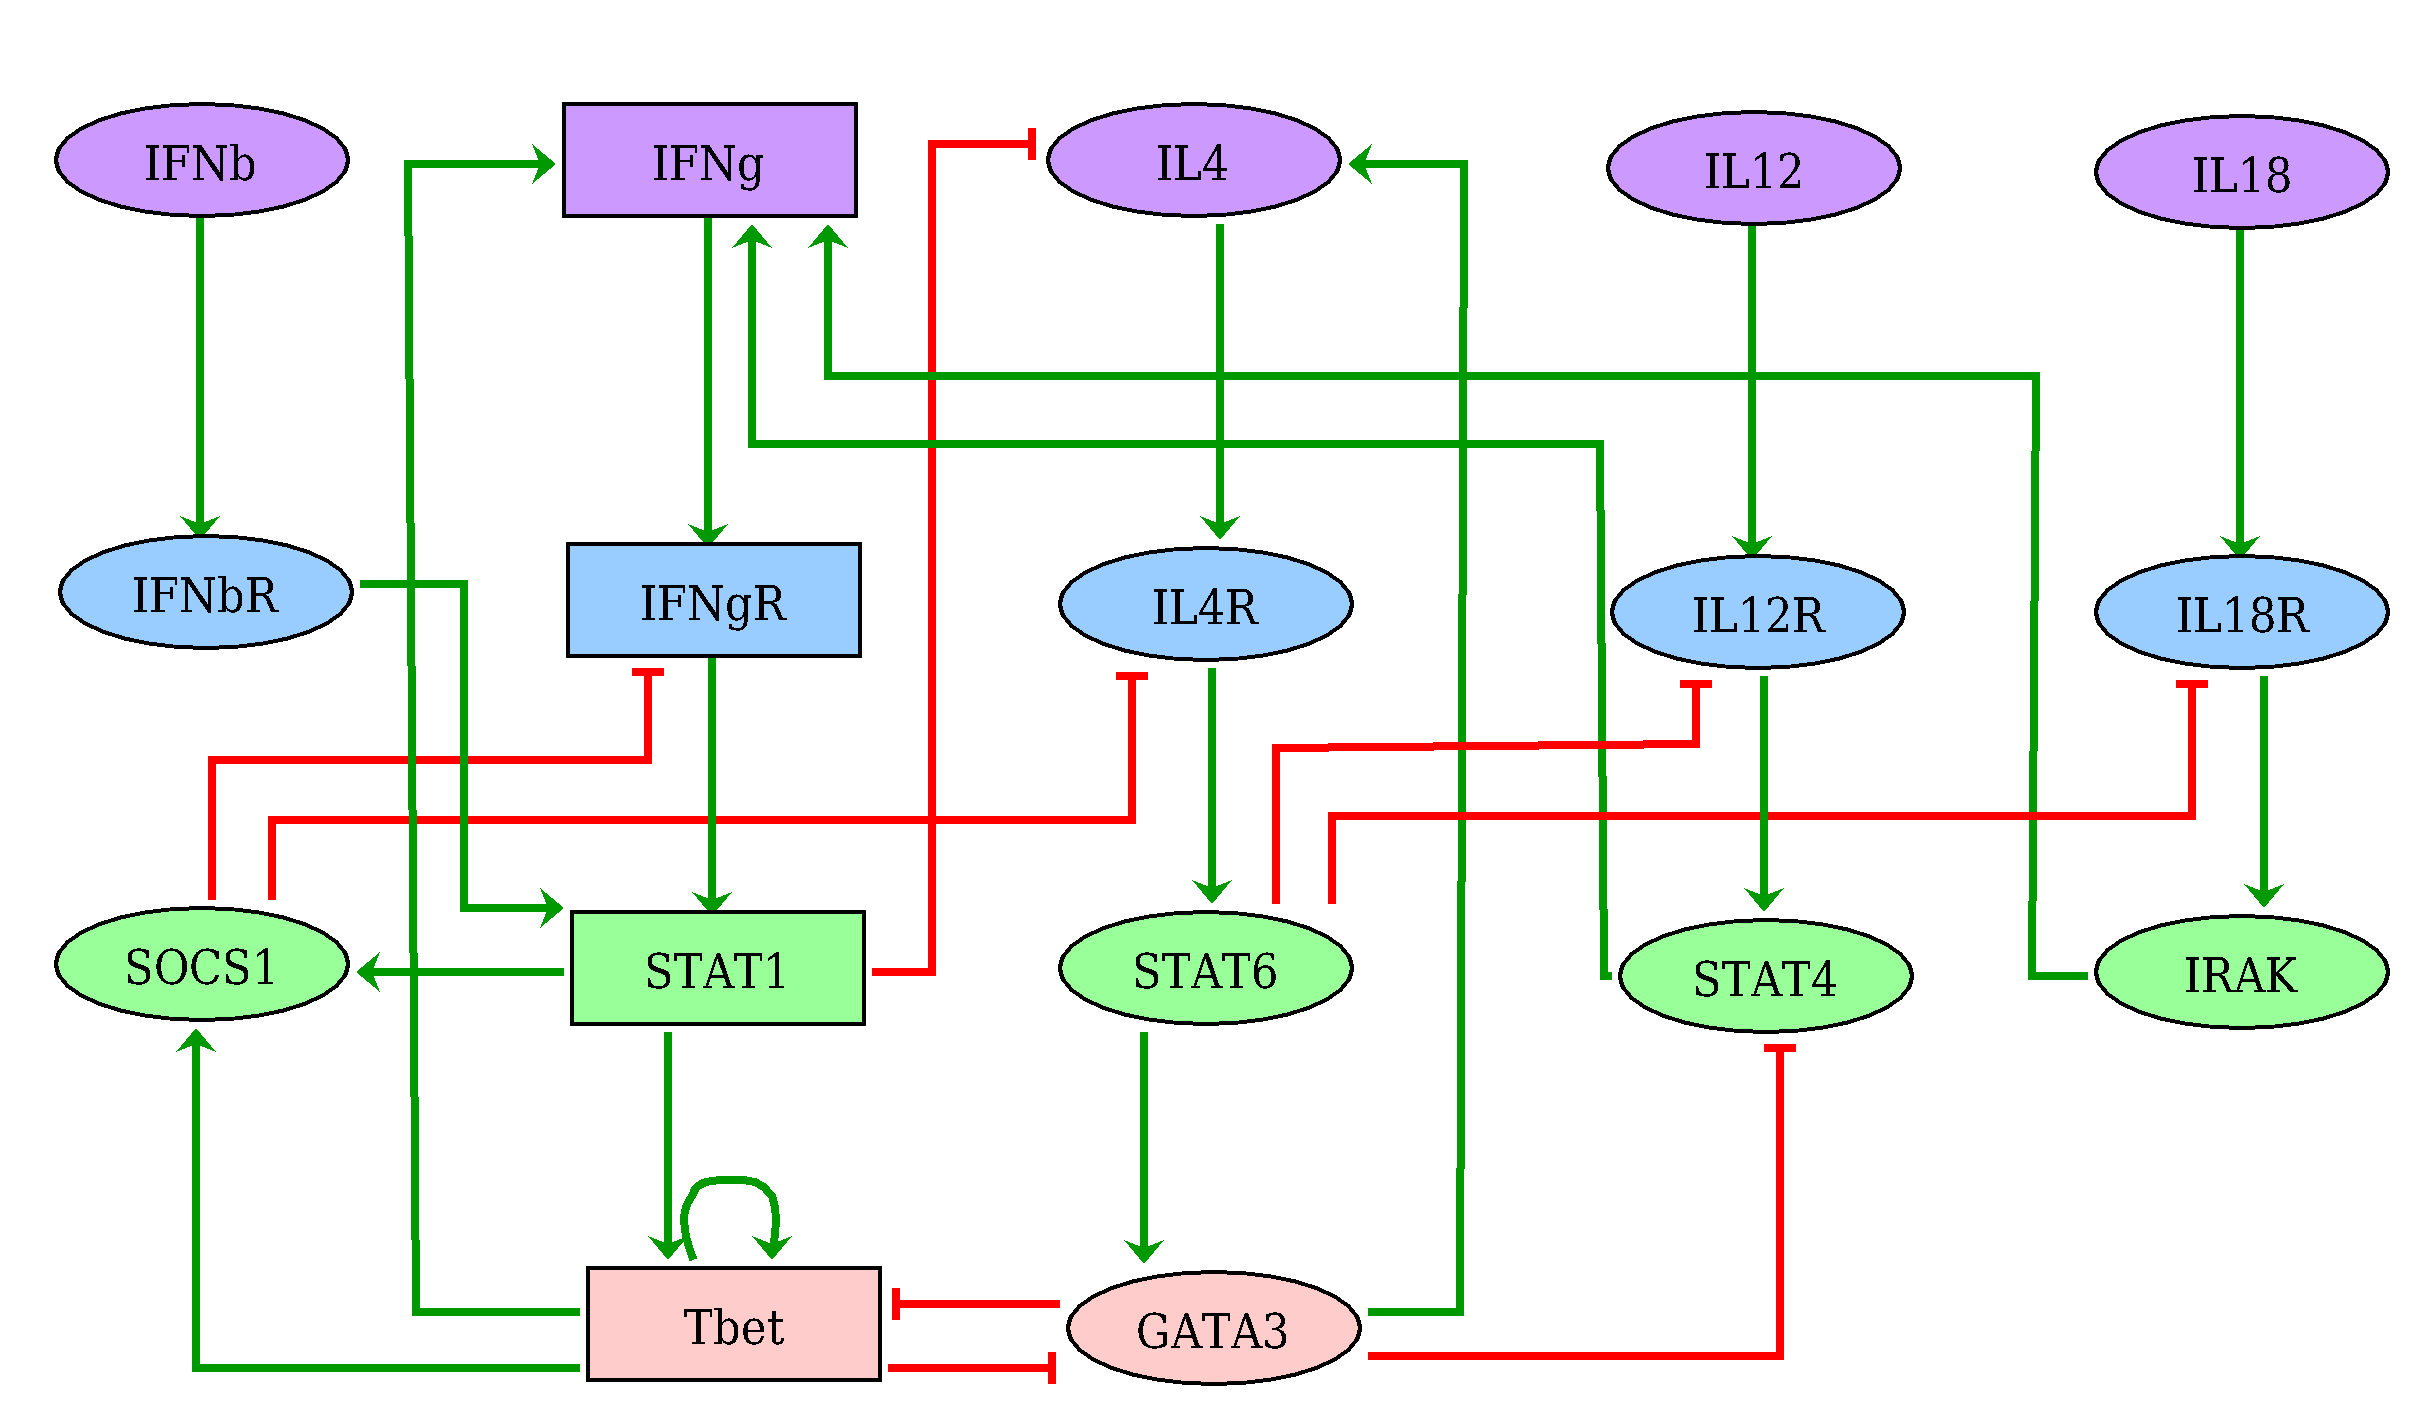

In [18]:
ginsim.show(th17)

In [19]:
lqm_1 = ginsim.to_biolqm(th17)

In [20]:
Test1 = biolqm.to_minibn(lqm_1)

In [21]:
Test1

GATA3 <- !Tbet:1&STAT6
IFNb <- 0
IFNbR <- IFNb
IFNg:1 <- (!Tbet:1&!IRAK&STAT4)|(Tbet:1&!Tbet:2&!IRAK)|(Tbet:1&!Tbet:2&IRAK&!STAT4)
IFNg:2 <- (!Tbet:1&IRAK&STAT4)|(Tbet:1&!Tbet:2&IRAK&STAT4)|Tbet:2
IFNgR:1 <- (IFNg:1&!IFNg:2)|(IFNg:2&SOCS1)
IFNgR:2 <- IFNg:2&!SOCS1
IL12 <- 0
IL12R <- IL12&!STAT6
IL18 <- 0
IL18R <- IL18&!STAT6
IL4 <- !STAT1:1&GATA3
IL4R <- !SOCS1&IL4
IRAK <- IL18R
SOCS1 <- (!STAT1:1&Tbet:1)|STAT1:1
STAT1:1 <- (!IFNgR:1&IFNbR)|(IFNgR:1&!IFNgR:2)
STAT1:2 <- IFNgR:2
STAT4 <- IL12R&!GATA3
STAT6 <- IL4R
Tbet:1 <- (!STAT1:1&Tbet:1&!Tbet:2&!GATA3)|(STAT1:1&!STAT1:2&!Tbet:1&!GATA3)|(STAT1:1&!STAT1:2&Tbet:1&!Tbet:2)
Tbet:2 <- (!STAT1:1&Tbet:2&!GATA3)|(STAT1:1&!STAT1:2&Tbet:2)|(STAT1:2&!GATA3)

In [22]:
lrg_2 = ginsim.load("/tmp/colomoto8iavmlrl_mymodel.ginml")

AssertionError: 

In [ ]:
lrg_2

In [ ]:
ginsim.show(lrg_2)

In [ ]:
lrg = biolqm.to_ginsim(lqm)

In [ ]:
F1 = BooleanNetwork()
A,B,C  = F1.vars("A", "B", "C")
F1[A] = C
F1[B] = A
F1[C] = B&~A


In [ ]:
F1